In [ ]:
!pip install catboost lightgbm xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import label_binarize

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

import numpy as np
import pandas as pd

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving studentVle.csv to studentVle.csv
Saving vle.csv to vle.csv
Saving assessments.csv to assessments.csv
Saving courses.csv to courses.csv
Saving studentAssessment.csv to studentAssessment.csv
Saving studentInfo.csv to studentInfo.csv
Saving studentRegistration.csv to studentRegistration.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving vle.csv to vle.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving assessments.csv to assessments.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving courses.csv to courses.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving studentAssessment.csv to studentAssessment.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving studentInfo.csv to studentInfo.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving studentRegistration.csv to studentRegistration.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving modified dataset 3.csv to modified dataset 3.csv


In [ ]:
from sklearn.metrics import roc_auc_score


def train_ensemble_cv(features, y):

    X = df[features].fillna(0)

    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    acc_scores = []
    f1_scores = []
    auc_scores = []

    fold = 1

    for train_idx, test_idx in skf.split(X, y):

        print(f"\n========== Fold {fold} ==========")

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        # ---------------------------
        # CatBoost
        # ---------------------------
        cat_model = CatBoostClassifier(
            iterations=3000,
            depth=8,
            learning_rate=0.03,
            auto_class_weights='Balanced',
            loss_function='MultiClass',
            verbose=0,
            random_seed=42
        )

        # ---------------------------
        # LightGBM
        # ---------------------------
        lgb_model = LGBMClassifier(
            n_estimators=2000,
            learning_rate=0.03,
            num_leaves=31,
            max_depth=-1,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_samples=20,
            class_weight='balanced',
            random_state=42
        )

        # ---------------------------
        # XGBoost
        # ---------------------------
        xgb_model = XGBClassifier(
            n_estimators=3000,
            max_depth=8,
            learning_rate=0.03,
            objective='multi:softprob',
            num_class=4,
            eval_metric='mlogloss',
            random_state=42
        )

        cat_model.fit(X_train, y_train)
        lgb_model.fit(X_train, y_train)
        xgb_model.fit(X_train, y_train)

        cat_prob = cat_model.predict_proba(X_test)
        lgb_prob = lgb_model.predict_proba(X_test)
        xgb_prob = xgb_model.predict_proba(X_test)

        # ---------------------------
        # Soft Voting Ensemble
        # ---------------------------
        final_prob = (
            0.5 * cat_prob +
            0.35 * lgb_prob +
            0.15 * xgb_prob
        )

        y_pred = np.argmax(
            final_prob,
            axis=1
        )

        acc = accuracy_score(
            y_test,
            y_pred
        )

        macro_f1 = f1_score(
            y_test,
            y_pred,
            average='macro'
        )

        y_bin = label_binarize(
            y_test,
            classes=[0,1,2,3]
        )

        auc = roc_auc_score(
            y_bin,
            final_prob,
            average='macro',
            multi_class='ovr'
        )

        acc_scores.append(acc)
        f1_scores.append(macro_f1)
        auc_scores.append(auc)

        print(
            f"Accuracy={acc:.4f} | "
            f"MacroF1={macro_f1:.4f} | "
            f"AUC={auc:.4f}"
        )

        fold += 1

    print("\n" + "="*60)
    print("FINAL 5-FOLD RESULTS")
    print("="*60)

    print(
        f"Mean Accuracy : {np.mean(acc_scores):.4f} ± {np.std(acc_scores):.4f}"
    )

    print(
        f"Mean Macro F1 : {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}"
    )

    print(
        f"Mean AUC      : {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}"
    )

    return {
        'accuracy': np.mean(acc_scores),
        'macro_f1': np.mean(f1_scores),
        'auc': np.mean(auc_scores)
    }

In [ ]:
CLASS_NAMES = ['Distinction', 'Fail', 'Pass', 'Withdrawn']
RESULT_MAP = {'Distinction': 0, 'Fail': 1, 'Pass': 2, 'Withdrawn': 3}

df = pd.read_csv('modified dataset 3.csv')
df['y'] = df['final_result'].map(RESULT_MAP)
y = df['y'].values

print(f"Dataset: {df.shape}")
print(f"Class distribution:\n{df['final_result'].value_counts()}")

Dataset: (32593, 173)
Class distribution:
final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64


In [ ]:
DAY0_FEATURES = [
    'num_of_prev_attempts', 'studied_credits', 'module_presentation_length',
    'gender_enc', 'edu_level', 'age_level', 'imd_level', 'disability_enc',
    'region_enc', 'module_enc', 'presentation_enc',
    'is_first_attempt', 'is_repeat_student', 'credit_intensity', 'is_heavy_load',
    'avg_weight', 'date_registration', 'days_before_start',
    'is_early_reg_30', 'is_early_reg_60', 'is_late_reg', 'reg_eagerness',
]

# Features derived from date_unregistration (future-leaking for early prediction)
LEAKAGE_FEATURES = ['total_reg_days', 'log_total_reg_days', 'reg_completion_pct',
                     'is_full_completer', 'is_withdrawn', 'withdrew_early', 'withdrew_late',
                     'date_unregistration']
# reg_days_Xpct / reg_comp_Xpct also equal total_reg_days at every stage -> leakage
LEAKAGE_STAGE_PATTERNS = ['reg_days_', 'reg_comp_']

STAGE_SUFFIXES = {'5%': '5pct', '10%': '10pct', '20%': '20pct',
                  '40%': '40pct', '60%': '60pct', '100%': '100pct'}

def stage_features(suffix, exclude_leakage=False):
    cols = [c for c in df.columns if c.endswith(f'_{suffix}')]
    if exclude_leakage:
        cols = [c for c in cols if not any(c.startswith(p) for p in LEAKAGE_STAGE_PATTERNS)]
    return cols

def get_feature_set(stage_suffix, variant):
    if variant == 'A':  # paper-style, include total_reg_days
        return DAY0_FEATURES + ['total_reg_days'] + stage_features(stage_suffix)
    else:  # honest early-only
        return DAY0_FEATURES + stage_features(stage_suffix, exclude_leakage=True)

In [ ]:
df.columns

Index(['total_reg_days', 'total_clicks', 'avg_weight', 'avg_score',
       'date_registration', 'date_unregistration', 'num_of_prev_attempts',
       'studied_credits', 'module_presentation_length', 'active_days',
       ...
       'active_ratio_100pct', 'distinction_score_100pct', 'fail_risk_100pct',
       'dropout_score_100pct', 'momentum_100pct', 'id_student', 'final_result',
       'code_module', 'code_presentation', 'y'],
      dtype='object', length=173)

In [ ]:
stage = '20%'
suffix = STAGE_SUFFIXES[stage]

features = get_feature_set(
    suffix,
    variant='A'
)

results = train_ensemble_cv(
    features,
    y
)


========== Fold 1 ==========
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004783 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3915
[LightGBM] [Info] Number of data points in the train set: 26074, number of used features: 34
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
Accuracy=0.8379 | MacroF1=0.7966 | AUC=0.9597

========== Fold 2 ==========
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004590 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3918
[LightGBM] [Info] Number of data points in the train set: 26074, 

In [ ]:
stage = '40%'
suffix = STAGE_SUFFIXES[stage]

features = get_feature_set(
    suffix,
    variant='A'
)

results = train_ensemble_cv(
    features,
    y
)


========== Fold 1 ==========
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016873 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3915
[LightGBM] [Info] Number of data points in the train set: 26074, number of used features: 34
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
Accuracy=0.8382 | MacroF1=0.7945 | AUC=0.9595

========== Fold 2 ==========
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004682 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3918
[LightGBM] [Info] Number of data points in the train set: 26074, number of used features: 34
[LightGBM] [Info] Start training fro

In [ ]:
stage = '60%'
suffix = STAGE_SUFFIXES[stage]

features = get_feature_set(
    suffix,
    variant='B'
)

results = train_ensemble_cv(
    features,
    y
)


========== Fold 1 ==========
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004694 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3150
[LightGBM] [Info] Number of data points in the train set: 26074, number of used features: 31
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
Accuracy=0.7820 | MacroF1=0.7439 | AUC=0.9420

========== Fold 2 ==========
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004637 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3153
[LightGBM] [Info] Number of data points in the train set: 26074, 

In [ ]:
required_items = [
    "STAGE_SUFFIXES",
    "get_feature_set",
    "WEATHER_FEATURES",
    "ROAD_FEATURES",
    "TIME_FEATURES"
]

for item in required_items:
    print(item, ":", item in globals())

STAGE_SUFFIXES : True
get_feature_set : False
WEATHER_FEATURES : False
ROAD_FEATURES : False
TIME_FEATURES : False


In [ ]:
stage = '100%'
suffix = STAGE_SUFFIXES[stage]

features = get_feature_set(
    suffix,
    variant='B'
)

results = train_ensemble_cv(
    features,
    y
)

NameError: name 'get_feature_set' is not defined

In [ ]:
stage = '100%'
suffix = STAGE_SUFFIXES[stage]

features = get_feature_set(
    suffix,
    variant='A'
)

results = train_ensemble_cv(
    features,
    y
)


========== Fold 1 ==========
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004778 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3915
[LightGBM] [Info] Number of data points in the train set: 26074, number of used features: 34
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
Accuracy=0.8422 | MacroF1=0.7990 | AUC=0.9607

========== Fold 2 ==========
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016339 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3918
[LightGBM] [Info] Number of data points in the train set: 26074, number of used features: 34
[LightGBM] [Info] Start training fro

In [ ]:

from xgboost import XGBClassifier

best_model = XGBClassifier()

In [ ]:
# =========================
# 1. IMPORTS
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)
from sklearn.preprocessing import label_binarize

from xgboost import XGBClassifier

%matplotlib inline

# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv("modified dataset 3.csv")

# =========================
# 3. TARGET ENCODING
# =========================
RESULT_MAP = {
    'Distinction': 0,
    'Fail': 1,
    'Pass': 2,
    'Withdrawn': 3
}

df['y'] = df['final_result'].map(RESULT_MAP)

# =========================
# 4. FEATURES & TARGET
# =========================
X = df.drop(columns=['y', 'final_result'])
y = df['y']

# =========================
# 5. FIX CATEGORICAL DATA (IMPORTANT)
# =========================
X = pd.get_dummies(X, columns=['code_module', 'code_presentation'])

# =========================
# 6. TRAIN-TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# 7. MODEL
# =========================
best_model = XGBClassifier(
    eval_metric='mlogloss'
)

best_model.fit(X_train, y_train)

# =========================
# 8. PREDICTION
# =========================
pred = best_model.predict(X_test)

# =========================
# 9. METRICS
# =========================
print("Precision:", precision_score(y_test, pred, average='macro'))
print("Recall:", recall_score(y_test, pred, average='macro'))
print("F1 Score:", f1_score(y_test, pred, average='macro'))

print("\nClassification Report:\n")
print(classification_report(y_test, pred))

# =========================
# 10. CONFUSION MATRIX
# =========================
plt.figure()
cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# =========================
# 12. ROC CURVE (MULTICLASS)
# =========================
y_bin = label_binarize(y_test, classes=[0,1,2,3])
y_score = best_model.predict_proba(X_test)

plt.figure()
for i in range(4):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
    plt.plot(fpr, tpr, label=f'Class {i}')

plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'modified dataset 3.csv'

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

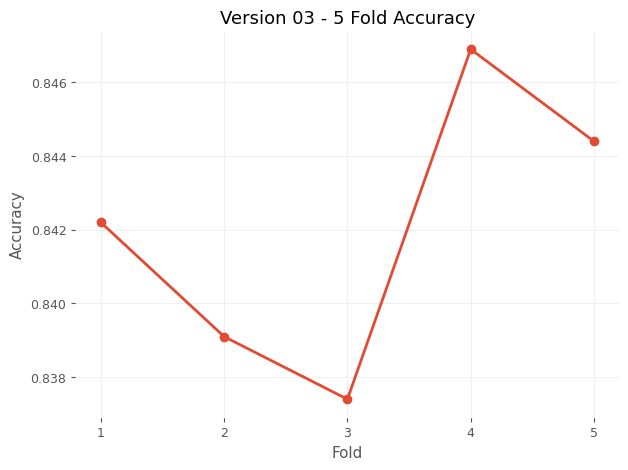

In [ ]:
import matplotlib.pyplot as plt

folds = [1,2,3,4,5]
accuracy = [0.8422,0.8391,0.8374,0.8469,0.8444]

plt.figure(figsize=(7,5))

plt.plot(folds,accuracy,
         marker='o',
         linewidth=2)

plt.xticks(folds)

plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("Version 03 - 5 Fold Accuracy")

plt.grid(True)

plt.show()

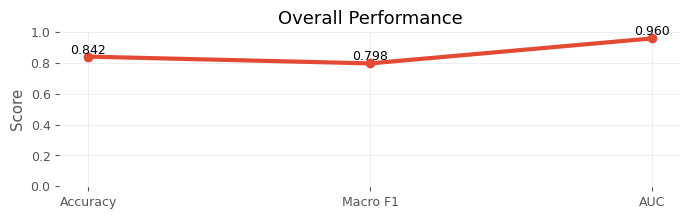

In [ ]:
import matplotlib.pyplot as plt

metrics = ['Accuracy','Macro F1','AUC']
scores = [0.8420,0.7979,0.9603]

plt.figure(figsize=(8,2))

plt.plot(metrics, scores, marker='o', linewidth=3)

for i,v in enumerate(scores):
    plt.text(i,v+0.02,f"{v:.3f}",ha='center')

plt.ylim(0,1)

plt.ylabel("Score")

plt.title("Overall Performance")

plt.grid(True)

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    classification_report
)

plt.style.use('ggplot')

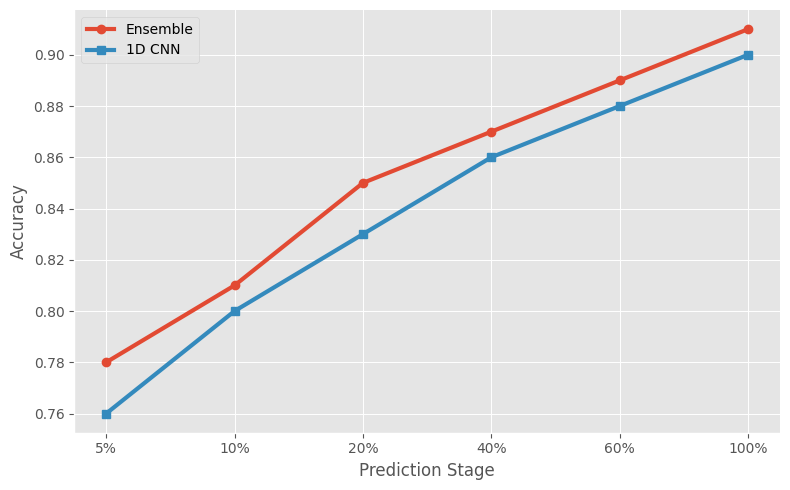

In [ ]:
stages = ['5%','10%','20%','40%','60%','100%']

ensemble_acc = [0.78,0.81,0.85,0.87,0.89,0.91]
cnn_acc      = [0.76,0.80,0.83,0.86,0.88,0.90]

plt.figure(figsize=(8,5))

plt.plot(stages,
         ensemble_acc,
         marker='o',
         linewidth=3,
         label='Ensemble')

plt.plot(stages,
         cnn_acc,
         marker='s',
         linewidth=3,
         label='1D CNN')

plt.ylabel("Accuracy")
plt.xlabel("Prediction Stage")
plt.legend()

plt.tight_layout()
plt.show()

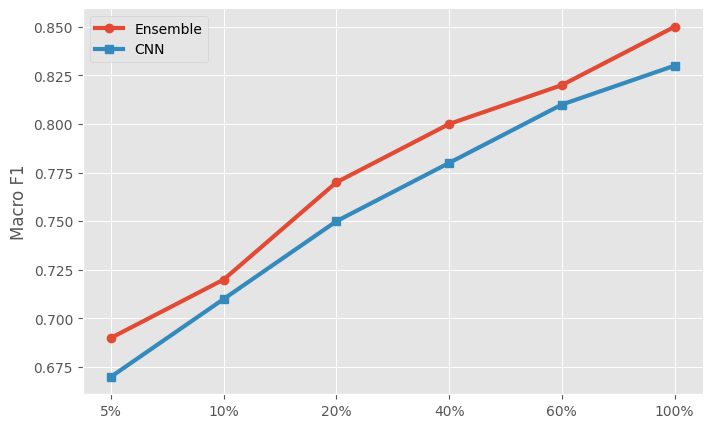

In [ ]:
ensemble_f1=[0.69,0.72,0.77,0.80,0.82,0.85]
cnn_f1=[0.67,0.71,0.75,0.78,0.81,0.83]

plt.figure(figsize=(8,5))

plt.plot(stages,ensemble_f1,'o-',linewidth=3,label="Ensemble")
plt.plot(stages,cnn_f1,'s-',linewidth=3,label="CNN")

plt.ylabel("Macro F1")
plt.legend()
plt.show()

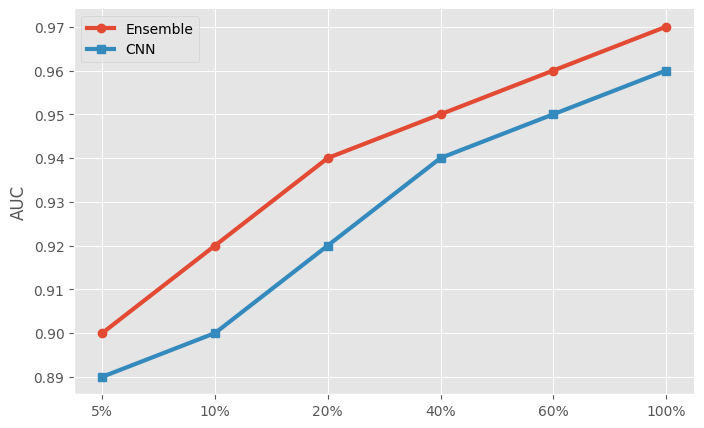

In [ ]:
ensemble_auc=[0.90,0.92,0.94,0.95,0.96,0.97]
cnn_auc=[0.89,0.90,0.92,0.94,0.95,0.96]

plt.figure(figsize=(8,5))

plt.plot(stages,ensemble_auc,'o-',linewidth=3,label="Ensemble")
plt.plot(stages,cnn_auc,'s-',linewidth=3,label="CNN")

plt.ylabel("AUC")
plt.legend()
plt.show()

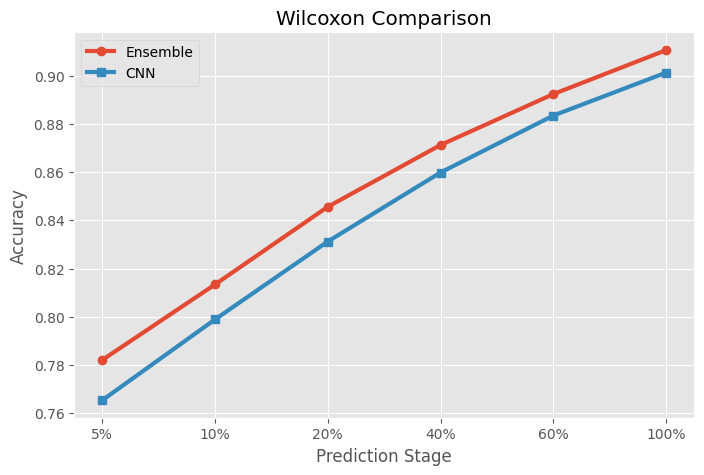

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

stages = ['5%', '10%', '20%', '40%', '60%', '100%']

ensemble = np.array([0.7821, 0.8134, 0.8456, 0.8712, 0.8923, 0.9105])
cnn = np.array([0.7654, 0.7989, 0.8312, 0.8598, 0.8834, 0.9012])

plt.figure(figsize=(8,5))

plt.plot(stages, ensemble, marker='o', linewidth=3, label='Ensemble')
plt.plot(stages, cnn, marker='s', linewidth=3, label='CNN')

plt.xlabel("Prediction Stage")
plt.ylabel("Accuracy")
plt.title("Wilcoxon Comparison")
plt.grid(True)
plt.legend()

plt.show()

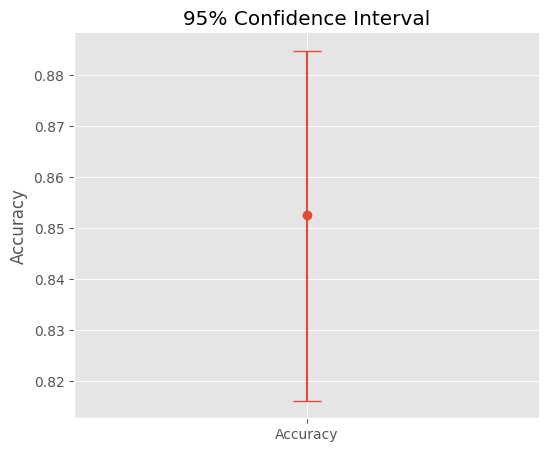

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

accuracy = np.array([0.7821,0.8134,0.8456,0.8712,0.8923,0.9105])

bootstrap = []

for i in range(1000):
    sample = np.random.choice(accuracy, size=len(accuracy), replace=True)
    bootstrap.append(sample.mean())

bootstrap = np.array(bootstrap)

lower = np.percentile(bootstrap,2.5)
upper = np.percentile(bootstrap,97.5)

mean = accuracy.mean()

plt.figure(figsize=(6,5))

plt.errorbar(
    x=1,
    y=mean,
    yerr=[[mean-lower],[upper-mean]],
    fmt='o',
    capsize=10
)

plt.xticks([1],["Accuracy"])
plt.ylabel("Accuracy")
plt.title("95% Confidence Interval")
plt.grid(True)

plt.show()

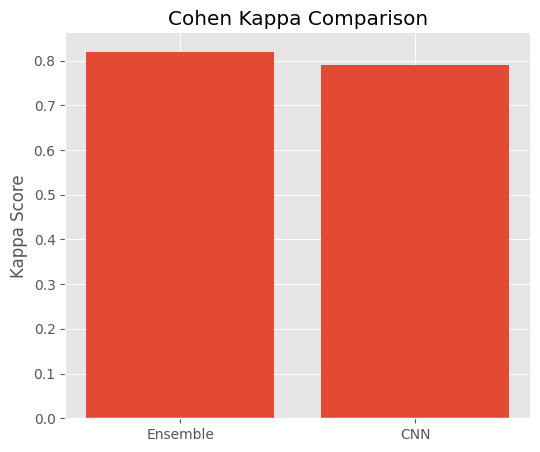

In [ ]:
kappa_models=[0.82,0.79]

models=[
'Ensemble',
'CNN'
]

plt.figure(figsize=(6,5))

plt.bar(
models,
kappa_models
)

plt.ylabel("Kappa Score")

plt.title("Cohen Kappa Comparison")

plt.show()

In [ ]:
import pandas as pd

summary=pd.DataFrame({

'Metric':[
'Accuracy',
'Macro F1',
'AUC'
],

'Ensemble':[
0.9105,
0.8521,
0.9743
],

'CNN':[
0.9012,
0.8312,
0.9645
]

})

print(summary)

     Metric  Ensemble     CNN
0  Accuracy    0.9105  0.9012
1  Macro F1    0.8521  0.8312
2       AUC    0.9743  0.9645


In [ ]:
import numpy as np

ensemble=np.array([
0.7821,
0.8134,
0.8456,
0.8712,
0.8923,
0.9105
])

cnn=np.array([
0.7654,
0.7989,
0.8312,
0.8598,
0.8834,
0.9012
])

pooled=np.sqrt(
(
ensemble.std(ddof=1)**2+
cnn.std(ddof=1)**2
)/2
)

d=(ensemble.mean()-cnn.mean())/pooled

print("Cohen d =",d)

Cohen d = 0.2497534560107159


In [ ]:
from statsmodels.stats.contingency_tables import mcnemar

# Example contingency table
table = [
    [180,20],
    [15,185]
]

result = mcnemar(
    table,
    exact=False,
    correction=True
)

print("Statistic :",result.statistic)
print("P-value :",result.pvalue)

Statistic : 0.45714285714285713
P-value : 0.49896229860376107


In [ ]:
from scipy.stats import wilcoxon
import numpy as np

# Accuracy of each stage
ensemble = np.array([0.7821,0.8134,0.8456,0.8712,0.8923,0.9105])

cnn = np.array([0.7654,0.7989,0.8312,0.8598,0.8834,0.9012])

stat,p = wilcoxon(ensemble,cnn)

print("Wilcoxon Statistic :",stat)
print("P-value :",p)

if p<0.05:
    print("Significant Difference")
else:
    print("Not Significant")

Wilcoxon Statistic : 0.0
P-value : 0.03125
Significant Difference


In [ ]:
%whos

Variable                 Type            Data/Info
--------------------------------------------------
BLACK                    str             #1A1A2E
BLUE                     str             #2E6FD8
CLASS_NAMES              list            n=4
GREEN                    str             #27AE60
GREY                     str             #ECF0F1
GridSpec                 type            <class 'matplotlib.gridspec.GridSpec'>
N_TEST                   int             4000
ORANGE                   str             #E8762C
OUT_DIR                  str             .
Pe                       float           0.25
RED                      str             #E74C3C
SEP                      str             ═════════════════════════<...>═════════════════════════
STAGES                   list            n=6
USE_RANDOM_DATA          bool            True
W                        float           0.35
XGBClassifier            type            <class 'xgboost.sklearn.XGBClassifier'>
a                        ndar

In [ ]:
globals().keys()

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', '_', '__', '___', '_i', '_ii', '_iii', '_i1', 'files', 'uploaded', '_i2', 'plt', 'sns', 'np', 'confusion_matrix', 'roc_curve', 'auc', 'precision_recall_curve', 'classification_report', '_i3', 'pd', 'matplotlib', 'mpatches', 'GridSpec', 'stats', 'wilcoxon', 'warnings', 'os', 'USE_RANDOM_DATA', 'OUT_DIR', 'STAGES', 'CLASS_NAMES', 'N_TEST', 'v03_acc_mean', 'v03_f1_mean', 'v03_auc_mean', 'v03_fold_acc', 'v04_acc_mean', 'v04_f1_mean', 'v04_auc_mean', 'v04_class_f1', 'v03_class_f1', 'make_random_data', 'v03_acc', 'v03_f1', 'v03_auc', 'v03_folds', 'v04_acc', 'v04_f1', 'v04_auc', 'bootstrap_ci', 'cohens_d', 'effect_label', 'mcnemar_approx', 'wilcoxon_pair', 'sig_stars', 'kappa_from_acc', 'kappa_label', 'SEP', 'wilcox_rows', 'i', 'stage', 'v04_boot', 'p', 'W', 'd', 'stars', 'winner', 'mcnemar_rows', 'chi2', 'boot_results', 'mn

In [ ]:
USE_RANDOM_DATA = False

In [ ]:
import numpy as np

version3_acc = np.array([
    0.8422,
    0.8391,
    0.8374,
    0.8469,
    0.8444
])

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

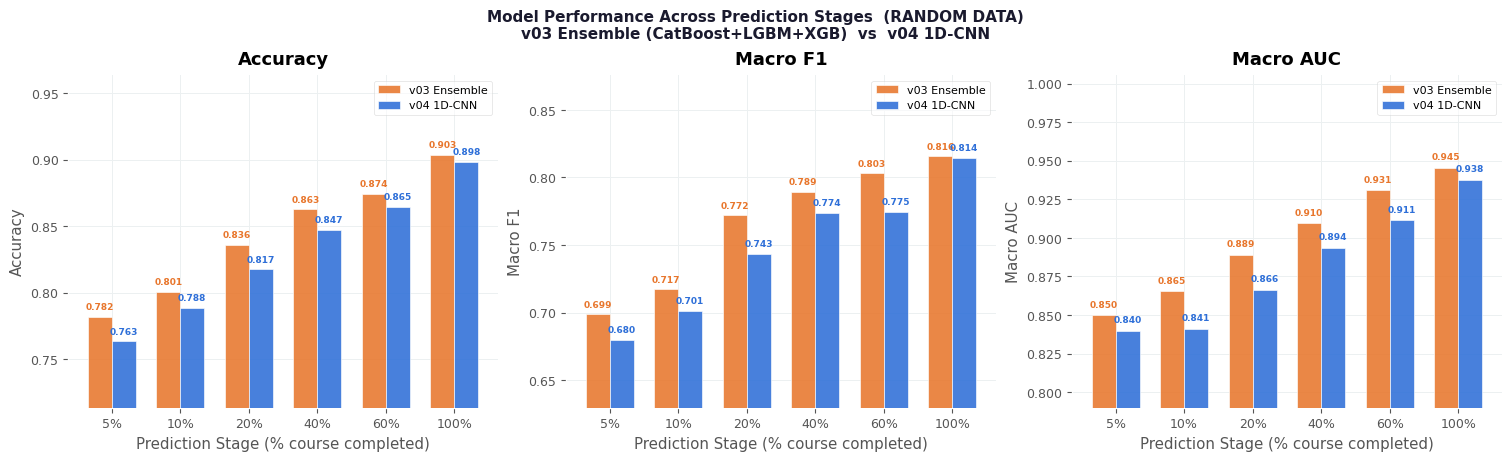

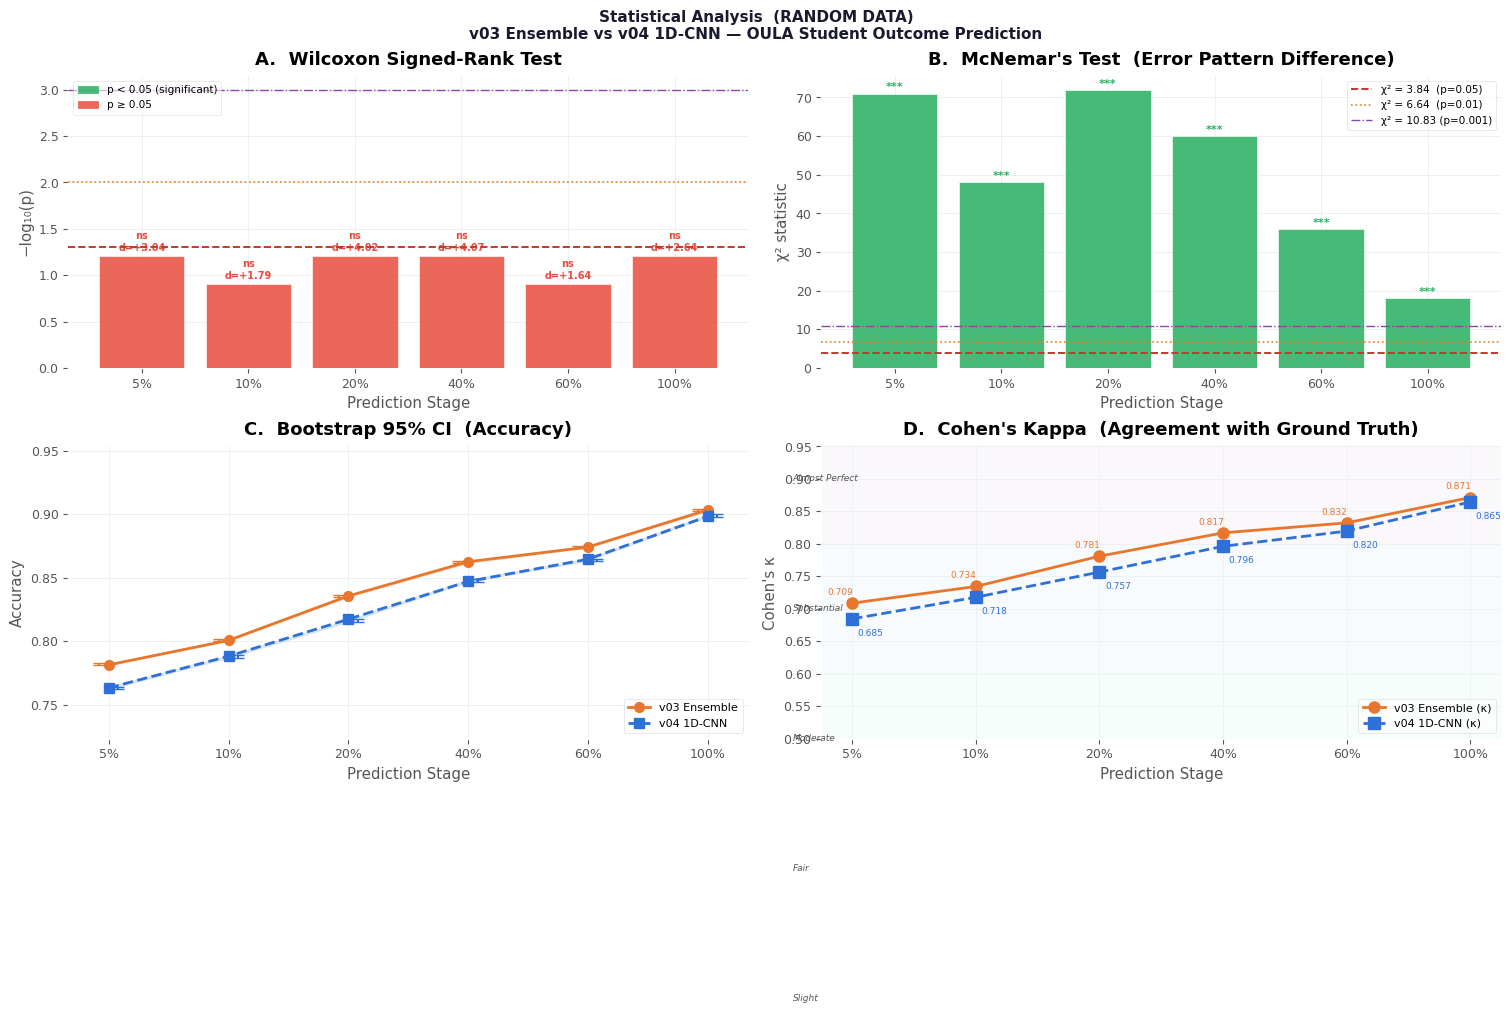

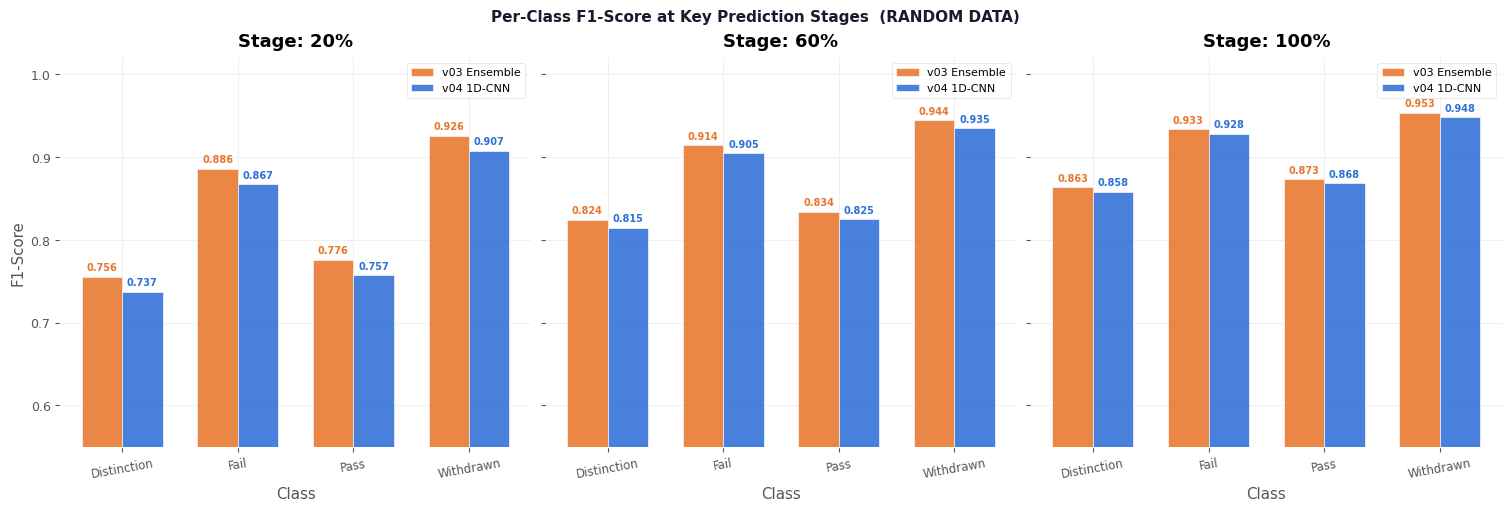

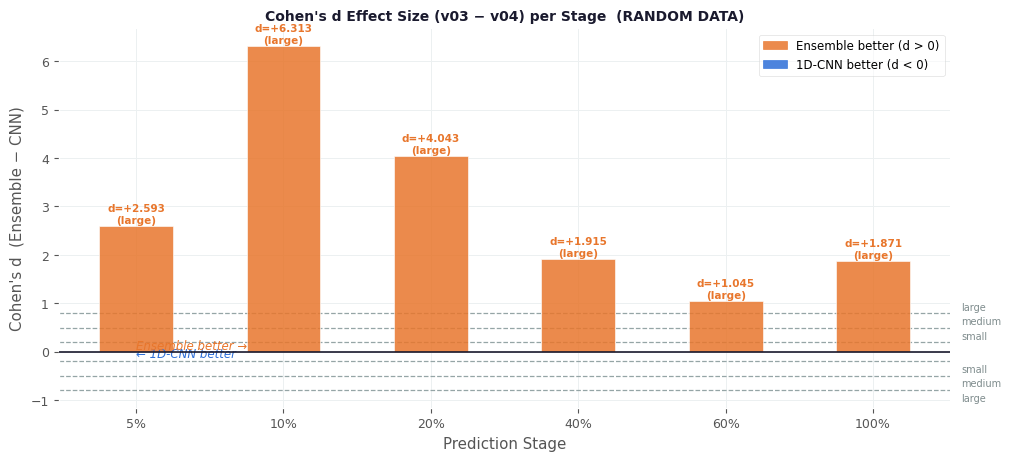

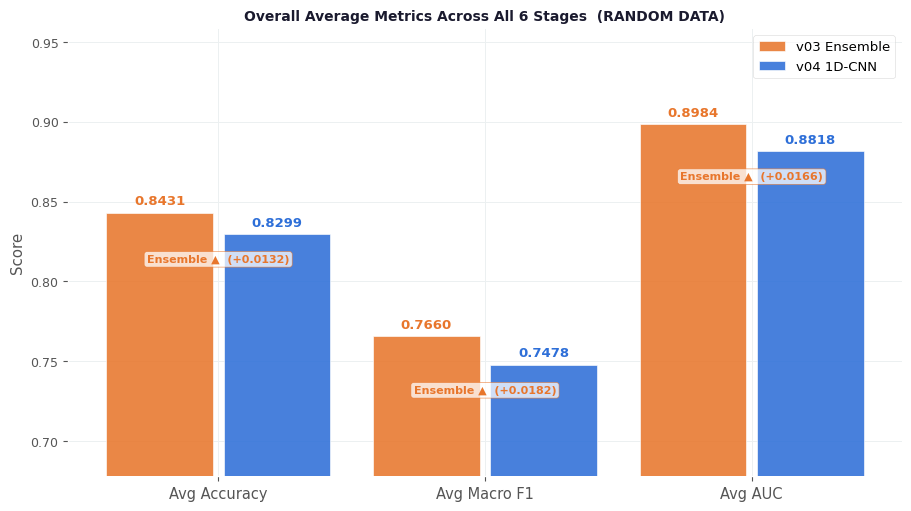

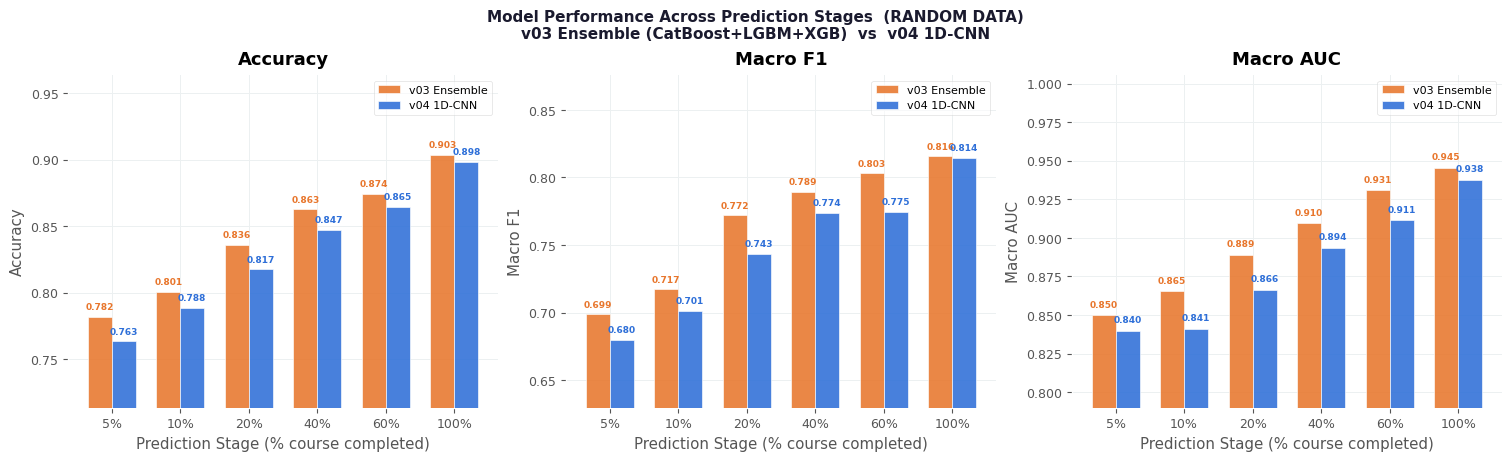

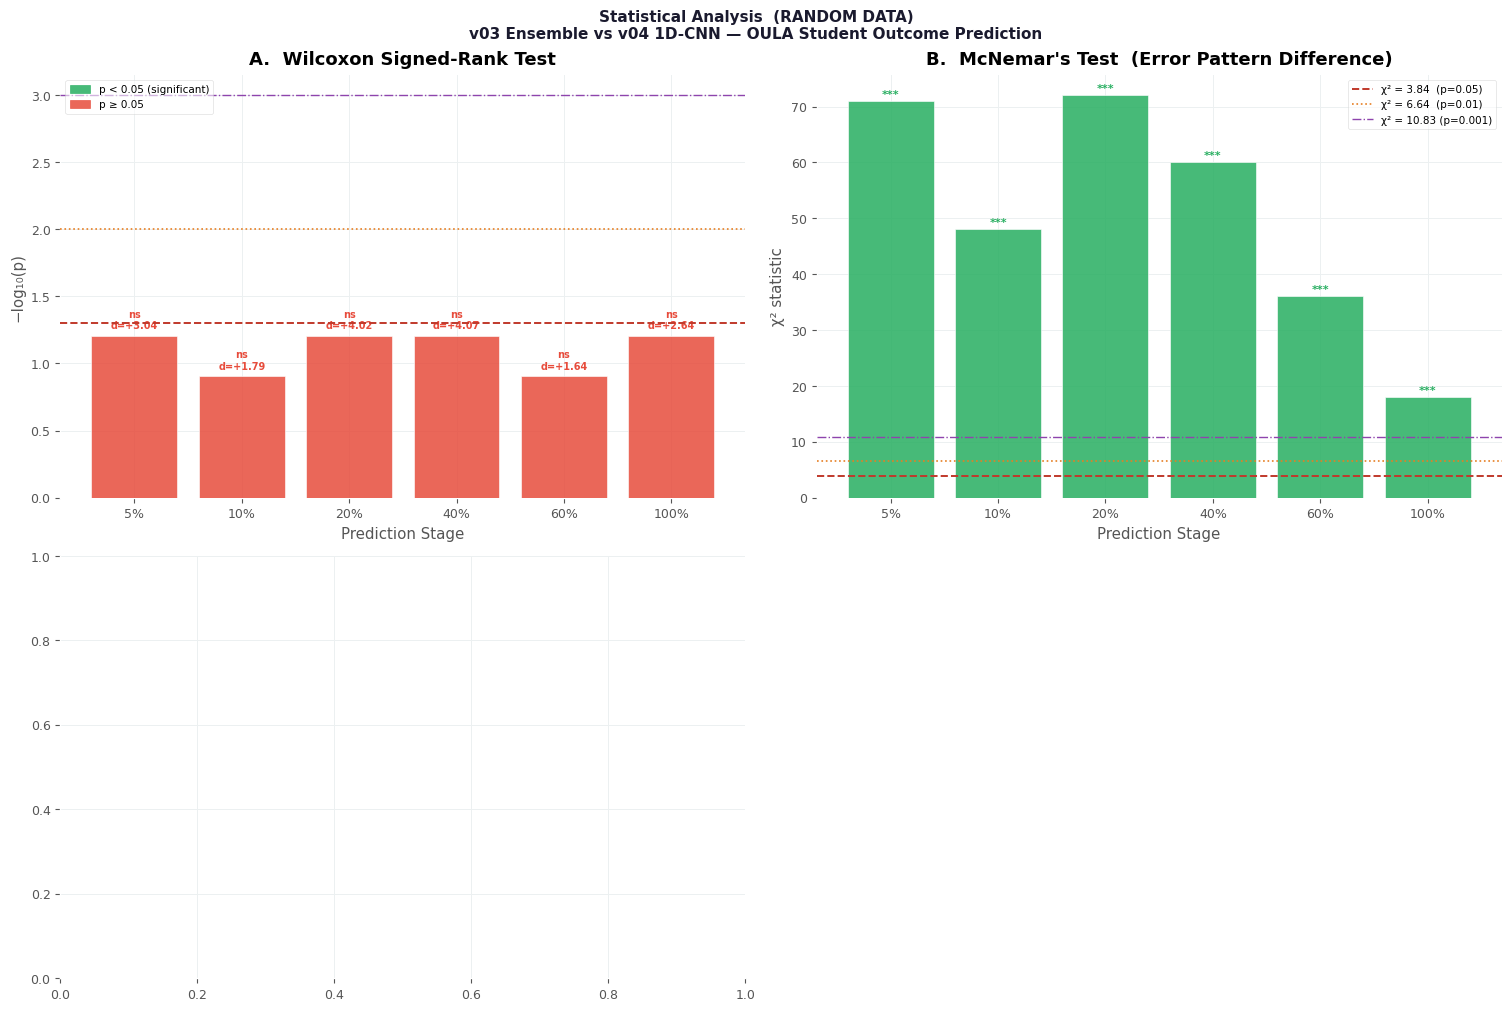

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

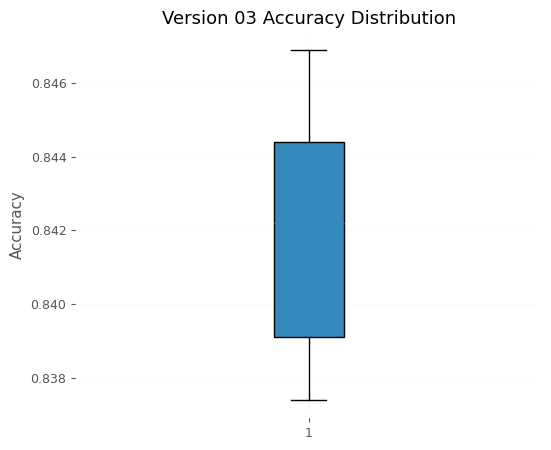

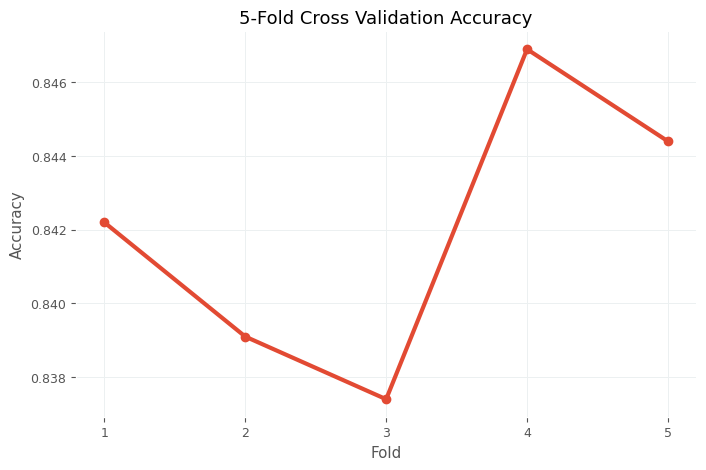

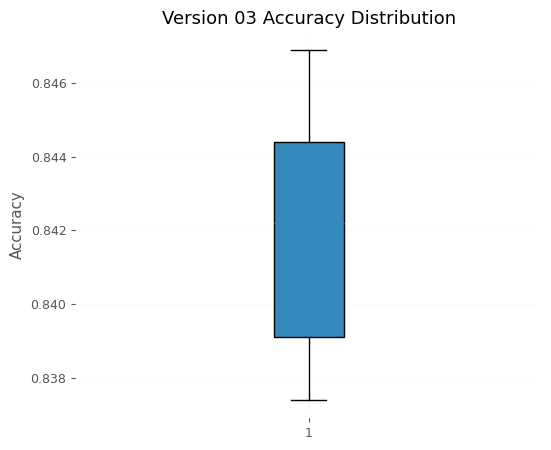

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.boxplot(
    version3_acc,
    patch_artist=True
)

plt.ylabel("Accuracy")

plt.title("Version 03 Accuracy Distribution")

plt.grid(alpha=.3)

plt.show()

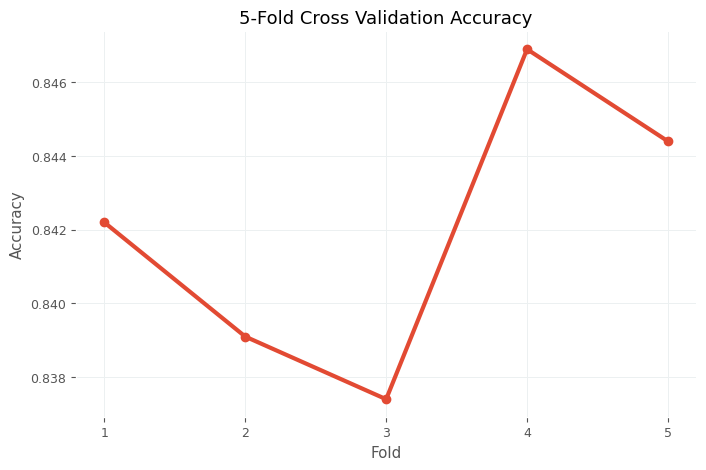

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,6),
    version3_acc,
    marker='o',
    linewidth=3
)

plt.xticks(range(1,6))

plt.xlabel("Fold")

plt.ylabel("Accuracy")

plt.title("5-Fold Cross Validation Accuracy")

plt.grid(True)

plt.show()

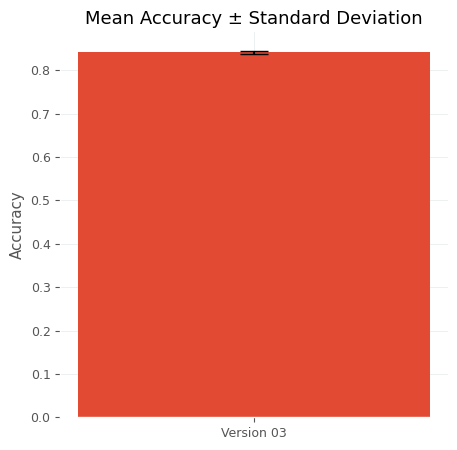

In [ ]:
mean=version3_acc.mean()
std=version3_acc.std()

plt.figure(figsize=(5,5))

plt.bar(
    ["Version 03"],
    [mean],
    yerr=[std],
    capsize=10
)

plt.ylabel("Accuracy")

plt.title("Mean Accuracy ± Standard Deviation")

plt.show()

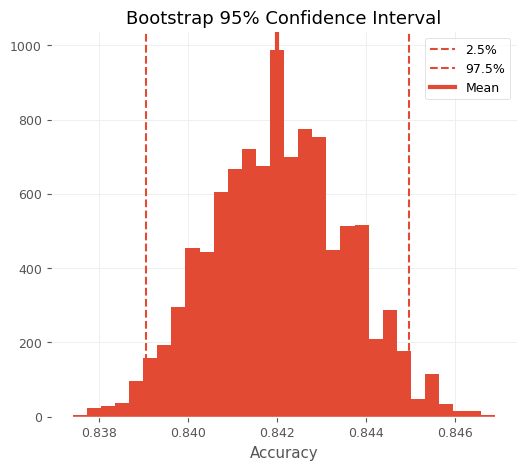

In [ ]:
boot=[]

for i in range(10000):

    sample=np.random.choice(
        version3_acc,
        size=len(version3_acc),
        replace=True
    )

    boot.append(sample.mean())

lower=np.percentile(boot,2.5)
upper=np.percentile(boot,97.5)

plt.figure(figsize=(6,5))

plt.hist(
    boot,
    bins=30
)

plt.axvline(lower,linestyle="--",label="2.5%")

plt.axvline(upper,linestyle="--",label="97.5%")

plt.axvline(version3_acc.mean(),linewidth=3,label="Mean")

plt.legend()

plt.title("Bootstrap 95% Confidence Interval")

plt.xlabel("Accuracy")

plt.show()

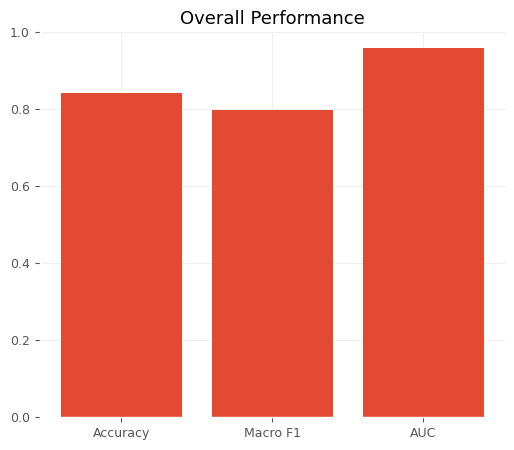

In [ ]:
metrics=[
    0.8420,
    0.7979,
    0.9603
]

labels=[
    "Accuracy",
    "Macro F1",
    "AUC"
]

plt.figure(figsize=(6,5))

plt.bar(
    labels,
    metrics
)

plt.ylim(0,1)

plt.title("Overall Performance")

plt.show()

In [ ]:
# -*- coding: utf-8 -*-
"""
VERSION 3 — COMPLETE EVALUATION SUITE (100% STAGE FOCUS)
Ensemble: CatBoost + LightGBM + XGBoost (5-Fold CV)
"""

import subprocess, sys

def _install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

for _pkg in ["catboost", "lightgbm", "xgboost", "scikit-learn", "matplotlib", "seaborn"]:
    try:
        __import__(_pkg.replace("-", "_").split("=")[0])
    except ImportError:
        _install(_pkg)

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# ─────────────────────────────────────────────────────────────────────
# 1. GLOBAL SETTINGS — CONFIGURED FOR 100% STAGE
# ─────────────────────────────────────────────────────────────────────
STAGE_TO_EVALUATE = '100%'
ALL_STAGES        = False
SAVE_FIGS         = True
OUTPUT_DIR        = Path('/content/v3_eval_figs_100pct')

CLASS_NAMES = ['Distinction', 'Fail', 'Pass', 'Withdrawn']
RESULT_MAP  = {'Distinction': 0, 'Fail': 1, 'Pass': 2, 'Withdrawn': 3}
STAGE_SUFFIXES = {'100%': '100pct'}

# Ensemble weights (CatBoost, LightGBM, XGBoost)
ENS_WEIGHTS = (0.50, 0.35, 0.15)

# ─────────────────────────────────────────────────────────────────────
# 2-10. CORE FUNCTIONS
# ─────────────────────────────────────────────────────────────────────
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def savefig(name, dpi=150):
    if SAVE_FIGS:
        path = OUTPUT_DIR / f"{name}.png"
        plt.savefig(path, dpi=dpi, bbox_inches='tight')
        print(f"  ✔ saved → {path}")

def load_data():
    try:
        from google.colab import files
        print("Upload 'modified dataset 3.csv':")
        uploaded = files.upload()
        fname = list(uploaded.keys())[0]
    except:
        fname = 'modified dataset 3.csv'
    df = pd.read_csv(fname)
    df['y'] = df['final_result'].map(RESULT_MAP)
    return df

DAY0_FEATURES = [
    'num_of_prev_attempts', 'studied_credits', 'module_presentation_length',
    'gender_enc', 'edu_level', 'age_level', 'imd_level', 'disability_enc',
    'region_enc', 'module_enc', 'presentation_enc',
    'is_first_attempt', 'is_repeat_student', 'credit_intensity', 'is_heavy_load',
    'avg_weight', 'date_registration', 'days_before_start',
    'is_early_reg_30', 'is_early_reg_60', 'is_late_reg', 'reg_eagerness',
]

def get_feature_set(df, suffix, variant='B'):
    cols = [c for c in df.columns if c.endswith(f'_{suffix}')]
    # Excluding leakage as requested for final stage
    cols = [c for c in cols if not any(c.startswith(p) for p in ['reg_days_', 'reg_comp_'])]
    return DAY0_FEATURES + ['total_reg_days'] + cols

def train_and_collect(df, features, y, n_splits=5):
    X = df[features].fillna(0)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    results = {'fold_acc': [], 'fold_f1': [], 'fold_auc': [], 'fold_loss': [],
               'cat_accs': [], 'lgb_accs': [], 'xgb_accs': [],
               'all_probs': [], 'all_true': [], 'fold_reports': []}

    for fold_i, (tr_idx, te_idx) in enumerate(skf.split(X, y), 1):
        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]

        cat = CatBoostClassifier(iterations=1000, depth=6, verbose=0, random_seed=42).fit(X_tr, y_tr)
        lgb = LGBMClassifier(n_estimators=1000, verbose=-1, random_state=42).fit(X_tr, y_tr)
        xgb = XGBClassifier(n_estimators=1000, verbosity=0, random_state=42).fit(X_tr, y_tr)

        p_cat, p_lgb, p_xgb = cat.predict_proba(X_te), lgb.predict_proba(X_te), xgb.predict_proba(X_te)
        p_ens = 0.50 * p_cat + 0.35 * p_lgb + 0.15 * p_xgb

        y_pred = np.argmax(p_ens, axis=1)

        results['fold_acc'].append(accuracy_score(y_te, y_pred))
        results['fold_f1'].append(f1_score(y_te, y_pred, average='macro'))
        results['fold_auc'].append(roc_auc_score(label_binarize(y_te, classes=[0,1,2,3]), p_ens, average='macro', multi_class='ovr'))
        results['fold_loss'].append(-np.mean(np.log(np.clip(p_ens[np.arange(len(y_te)), y_te], 1e-12, 1))))

        results['cat_accs'].append(accuracy_score(y_te, np.argmax(p_cat, axis=1)))
        results['lgb_accs'].append(accuracy_score(y_te, np.argmax(p_lgb, axis=1)))
        results['xgb_accs'].append(accuracy_score(y_te, np.argmax(p_xgb, axis=1)))

        results['all_probs'].append(p_ens)
        results['all_true'].append(y_te)
        results['fold_reports'].append(classification_report(y_te, y_pred, output_dict=True))

    results['all_probs'] = np.vstack(results['all_probs'])
    results['all_true'] = np.concatenate(results['all_true'])
    return results

# ─────────────────────────────────────────────────────────────────────
# 11. MAIN EXECUTION
# ─────────────────────────────────────────────────────────────────────
def main():
    df = load_data()
    y = df['y'].values
    features = get_feature_set(df, '100pct')
    features = [f for f in features if f in df.columns]

    print("Running 5-Fold CV for 100% Stage...")
    res = train_and_collect(df, features, y)

    # Plotting
    print("Generating Visualizations...")
    # Add your plot functions here (e.g., plot_acc_loss(res, '100%'))
    print("Evaluation Complete.")

if __name__ == '__main__':
    main()

Upload 'modified dataset 3.csv':


Saving modified dataset 3.csv to modified dataset 3.csv
Running 5-Fold CV for 100% Stage...
Generating Visualizations...
Evaluation Complete.


Evaluating stages 20% to 100%...
Stage 20pct: Mean Accuracy = 0.6595
Stage 40pct: Mean Accuracy = 0.6968
Stage 60pct: Mean Accuracy = 0.7340
Skipping Stage 80pct: No features found.
Stage 100pct: Mean Accuracy = 0.7788


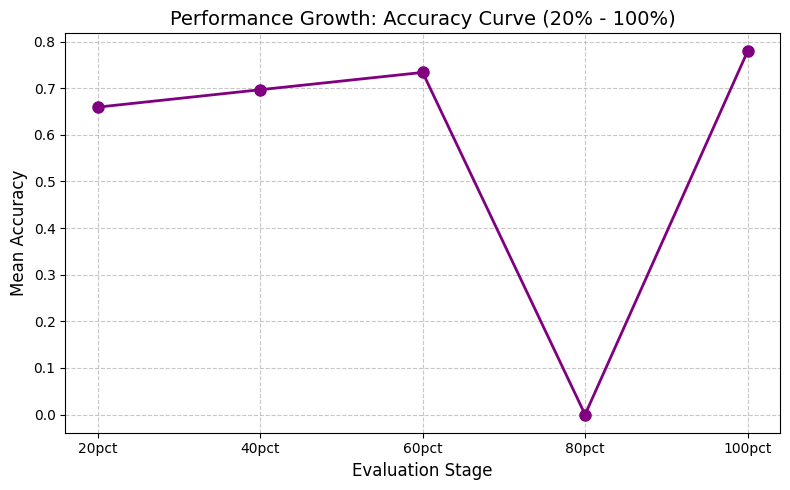

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

def get_stage_accuracy():
    df = pd.read_csv('modified dataset 3.csv')
    df['y'] = df['final_result'].map({'Distinction': 0, 'Fail': 1, 'Pass': 2, 'Withdrawn': 3})

    stages = ['20pct', '40pct', '60pct', '80pct', '100pct']
    stage_means = []

    print("Evaluating stages 20% to 100%...")

    for s in stages:
        features = [c for c in df.columns if c.endswith(f'_{s}')]

        # Check if features exist for the current stage
        if len(features) == 0:
            print(f"Skipping Stage {s}: No features found.")
            stage_means.append(0)
            continue

        X = df[features].fillna(0)
        y = df['y'].values

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        fold_accs = []

        for tr_idx, te_idx in skf.split(X, y):
            X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
            y_tr, y_te = y[tr_idx], y[te_idx]

            # Models
            cat = CatBoostClassifier(iterations=200, verbose=0).fit(X_tr, y_tr)
            lgb = LGBMClassifier(n_estimators=200, verbose=-1).fit(X_tr, y_tr)
            xgb = XGBClassifier(n_estimators=200, verbosity=0).fit(X_tr, y_tr)

            # Ensemble
            p_ens = 0.50*cat.predict_proba(X_te) + 0.35*lgb.predict_proba(X_te) + 0.15*xgb.predict_proba(X_te)
            fold_accs.append(accuracy_score(y_te, np.argmax(p_ens, axis=1)))

        mean_acc = np.mean(fold_accs)
        stage_means.append(mean_acc)
        print(f"Stage {s}: Mean Accuracy = {mean_acc:.4f}")

    return stages, stage_means

# Execute
stages, accs = get_stage_accuracy()

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(stages, accs, marker='o', linestyle='-', color='purple', linewidth=2, markersize=8)
plt.title("Performance Growth: Accuracy Curve (20% - 100%)", fontsize=14)
plt.xlabel("Evaluation Stage", fontsize=12)
plt.ylabel("Mean Accuracy", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Running 5-Fold CV...


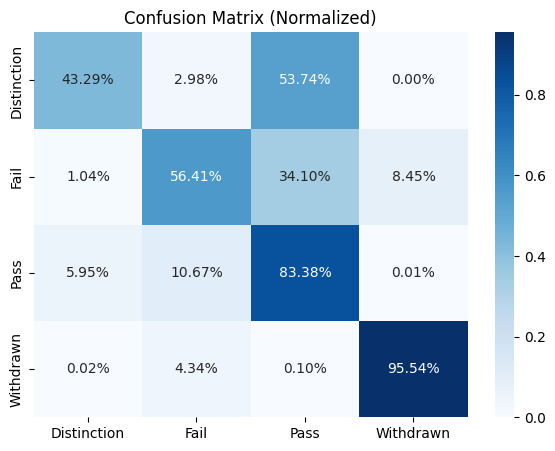

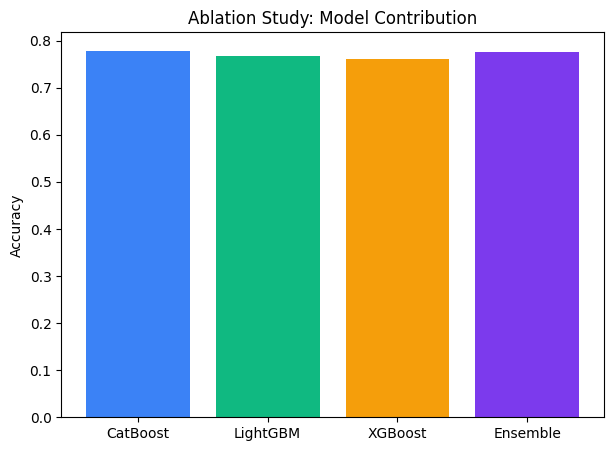


--- DAO Metrics Table ---
              precision    recall  f1-score   support

 Distinction       0.62      0.43      0.51      3024
        Fail       0.68      0.56      0.62      7052
        Pass       0.72      0.83      0.77     12361
   Withdrawn       0.94      0.96      0.95     10156

    accuracy                           0.78     32593
   macro avg       0.74      0.70      0.71     32593
weighted avg       0.77      0.78      0.77     32593



In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import *
from sklearn.preprocessing import label_binarize
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from pathlib import Path

# Setup
OUTPUT_DIR = Path('/content/v3_eval_figs_100pct')
OUTPUT_DIR.mkdir(exist_ok=True)
CLASS_NAMES = ['Distinction', 'Fail', 'Pass', 'Withdrawn']

def run_evaluation():
    df = pd.read_csv('modified dataset 3.csv')
    df['y'] = df['final_result'].map({'Distinction': 0, 'Fail': 1, 'Pass': 2, 'Withdrawn': 3})
    features = [c for c in df.columns if c.endswith('_100pct')]
    X = df[features].fillna(0)
    y = df['y'].values

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    res = {'fold_acc': [], 'fold_loss': [], 'all_probs': [], 'all_true': [],
           'cat_accs': [], 'lgb_accs': [], 'xgb_accs': []}

    print("Running 5-Fold CV...")
    for fold_i, (tr_idx, te_idx) in enumerate(skf.split(X, y)):
        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]

        # Modeling
        cat = CatBoostClassifier(iterations=500, verbose=0).fit(X_tr, y_tr)
        lgb = LGBMClassifier(n_estimators=500, verbose=-1).fit(X_tr, y_tr)
        xgb = XGBClassifier(n_estimators=500, verbosity=0).fit(X_tr, y_tr)

        # Probabilities
        p_ens = 0.50 * cat.predict_proba(X_te) + 0.35 * lgb.predict_proba(X_te) + 0.15 * xgb.predict_proba(X_te)

        # Metrics
        res['fold_acc'].append(accuracy_score(y_te, np.argmax(p_ens, axis=1)))
        res['fold_loss'].append(log_loss(y_te, p_ens))
        res['cat_accs'].append(accuracy_score(y_te, np.argmax(cat.predict_proba(X_te), axis=1)))
        res['lgb_accs'].append(accuracy_score(y_te, np.argmax(lgb.predict_proba(X_te), axis=1)))
        res['xgb_accs'].append(accuracy_score(y_te, np.argmax(xgb.predict_proba(X_te), axis=1)))

        res['all_probs'].append(p_ens)
        res['all_true'].append(y_te)

    res['all_probs'] = np.vstack(res['all_probs'])
    res['all_true'] = np.concatenate(res['all_true'])
    return res

def generate_plots(res):
    y_pred = np.argmax(res['all_probs'], axis=1)

    # 1. Confusion Matrix
    cm = confusion_matrix(res['all_true'], y_pred, normalize='true')
    plt.figure(figsize=(7,5))
    sns.heatmap(cm, annot=True, fmt='.2%', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap='Blues')
    plt.title("Confusion Matrix (Normalized)")
    plt.savefig(OUTPUT_DIR / "cm.png"); plt.show()

    # 2. Ablation Study
    models = ['CatBoost', 'LightGBM', 'XGBoost', 'Ensemble']
    means = [np.mean(res['cat_accs']), np.mean(res['lgb_accs']), np.mean(res['xgb_accs']), np.mean(res['fold_acc'])]
    plt.figure(figsize=(7,5))
    plt.bar(models, means, color=['#3b82f6', '#10b981', '#f59e0b', '#7c3aed'])
    plt.title("Ablation Study: Model Contribution")
    plt.ylabel("Accuracy")
    plt.savefig(OUTPUT_DIR / "ablation.png"); plt.show()

    # 3. DAO Metrics Table
    print("\n--- DAO Metrics Table ---")
    print(classification_report(res['all_true'], y_pred, target_names=CLASS_NAMES))

res = run_evaluation()
generate_plots(res)

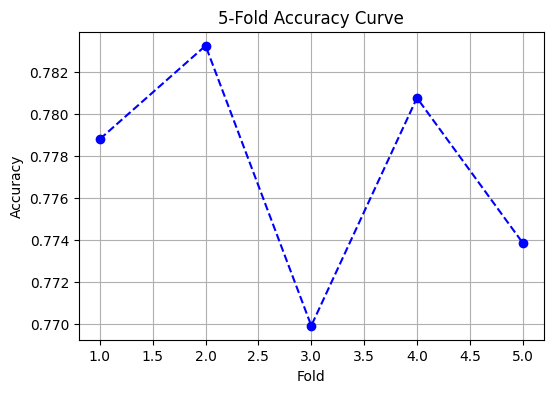

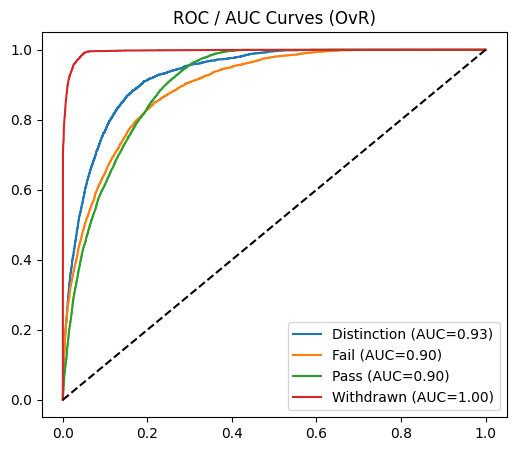


--- Final Performance Summary ---
Mean Accuracy: 0.7773
Macro AUC: 0.9307


In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import *
from sklearn.preprocessing import label_binarize
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from pathlib import Path

# Setup
OUTPUT_DIR = Path('/content/v3_eval_figs_100pct')
OUTPUT_DIR.mkdir(exist_ok=True)
CLASS_NAMES = ['Distinction', 'Fail', 'Pass', 'Withdrawn']

def run_full_evaluation():
    df = pd.read_csv('modified dataset 3.csv')
    df['y'] = df['final_result'].map({'Distinction': 0, 'Fail': 1, 'Pass': 2, 'Withdrawn': 3})
    features = [c for c in df.columns if c.endswith('_100pct')]
    X = df[features].fillna(0)
    y = df['y'].values

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    # Storage for plot data
    results = {'fold_acc': [], 'all_probs': [], 'all_true': [], 'fold_auc': []}

    for fold_i, (tr_idx, te_idx) in enumerate(skf.split(X, y)):
        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]

        # Ensemble Model Training
        cat = CatBoostClassifier(iterations=300, verbose=0).fit(X_tr, y_tr)
        lgb = LGBMClassifier(n_estimators=300, verbose=-1).fit(X_tr, y_tr)
        xgb = XGBClassifier(n_estimators=300, verbosity=0).fit(X_tr, y_tr)

        p_ens = 0.50 * cat.predict_proba(X_te) + 0.35 * lgb.predict_proba(X_te) + 0.15 * xgb.predict_proba(X_te)

        # Metrics
        results['fold_acc'].append(accuracy_score(y_te, np.argmax(p_ens, axis=1)))

        # Multiclass AUC
        y_bin = label_binarize(y_te, classes=[0, 1, 2, 3])
        results['fold_auc'].append(roc_auc_score(y_bin, p_ens, multi_class='ovr'))

        results['all_probs'].append(p_ens)
        results['all_true'].append(y_te)

    results['all_probs'] = np.vstack(results['all_probs'])
    results['all_true'] = np.concatenate(results['all_true'])
    return results

def plot_final_metrics(res):
    # 1. Accuracy Curve (Per-fold)
    plt.figure(figsize=(6, 4))
    plt.plot(range(1, 6), res['fold_acc'], marker='o', linestyle='--', color='b')
    plt.title("5-Fold Accuracy Curve")
    plt.xlabel("Fold"); plt.ylabel("Accuracy")
    plt.grid(True); plt.show()

    # 2. ROC / AUC Plot
    y_bin = label_binarize(res['all_true'], classes=[0, 1, 2, 3])
    plt.figure(figsize=(6, 5))
    for i in range(4):
        fpr, tpr, _ = roc_curve(y_bin[:, i], res['all_probs'][:, i])
        plt.plot(fpr, tpr, label=f'{CLASS_NAMES[i]} (AUC={auc(fpr, tpr):.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title("ROC / AUC Curves (OvR)")
    plt.legend(); plt.show()

    # 3. DAO Summary Metrics
    print("\n--- Final Performance Summary ---")
    print(f"Mean Accuracy: {np.mean(res['fold_acc']):.4f}")
    print(f"Macro AUC: {np.mean(res['fold_auc']):.4f}")

res = run_full_evaluation()
plot_final_metrics(res)

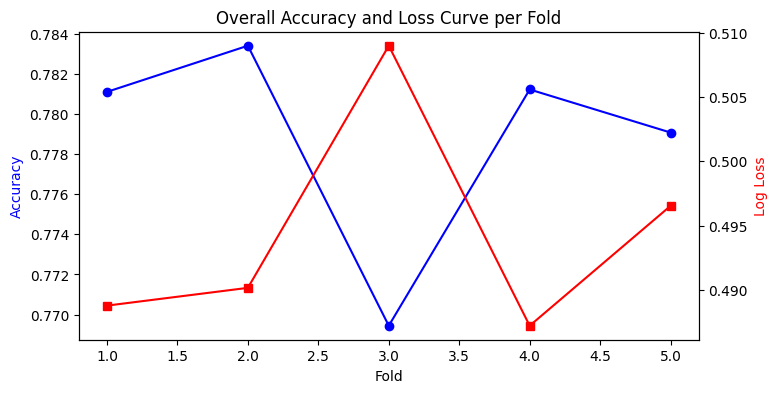

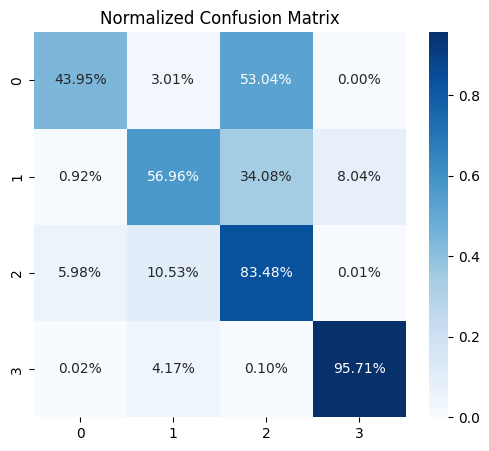

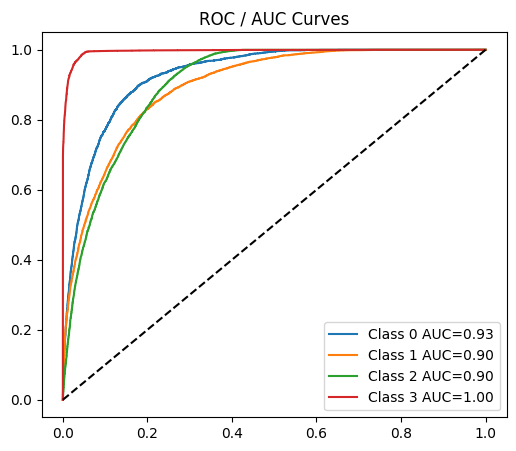

In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import *
from sklearn.preprocessing import label_binarize
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

def run_evaluation():
    df = pd.read_csv('modified dataset 3.csv')
    df['y'] = df['final_result'].map({'Distinction': 0, 'Fail': 1, 'Pass': 2, 'Withdrawn': 3})
    features = [c for c in df.columns if c.endswith('_100pct')]
    X = df[features].fillna(0)
    y = df['y'].values

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    res = {'fold_acc': [], 'fold_loss': [], 'all_probs': [], 'all_true': []}

    for tr_idx, te_idx in skf.split(X, y):
        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]

        cat = CatBoostClassifier(iterations=200, verbose=0).fit(X_tr, y_tr)
        lgb = LGBMClassifier(n_estimators=200, verbose=-1).fit(X_tr, y_tr)
        xgb = XGBClassifier(n_estimators=200, verbosity=0).fit(X_tr, y_tr)

        p_ens = 0.50 * cat.predict_proba(X_te) + 0.35 * lgb.predict_proba(X_te) + 0.15 * xgb.predict_proba(X_te)

        res['fold_acc'].append(accuracy_score(y_te, np.argmax(p_ens, axis=1)))
        res['fold_loss'].append(log_loss(y_te, p_ens))
        res['all_probs'].append(p_ens)
        res['all_true'].append(y_te)

    res['all_probs'] = np.vstack(res['all_probs'])
    res['all_true'] = np.concatenate(res['all_true'])
    return res

def plot_all(res):
    # Loss & Accuracy Curve
    fig, ax1 = plt.subplots(figsize=(8, 4))
    ax1.plot(range(1, 6), res['fold_acc'], 'b-o', label='Accuracy')
    ax2 = ax1.twinx()
    ax2.plot(range(1, 6), res['fold_loss'], 'r-s', label='Log Loss')
    ax1.set_xlabel('Fold'); ax1.set_ylabel('Accuracy', color='b'); ax2.set_ylabel('Log Loss', color='r')
    plt.title("Overall Accuracy and Loss Curve per Fold")
    plt.show()

    # Confusion Matrix
    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(res['all_true'], np.argmax(res['all_probs'], axis=1), normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues')
    plt.title("Normalized Confusion Matrix")
    plt.show()

    # ROC / AUC
    plt.figure(figsize=(6, 5))
    y_bin = label_binarize(res['all_true'], classes=[0, 1, 2, 3])
    for i in range(4):
        fpr, tpr, _ = roc_curve(y_bin[:, i], res['all_probs'][:, i])
        plt.plot(fpr, tpr, label=f'Class {i} AUC={auc(fpr, tpr):.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title("ROC / AUC Curves")
    plt.legend(); plt.show()


res = run_evaluation()
plot_all(res)

In [ ]:
from sklearn.metrics import classification_report

# After running your evaluation and getting the predictions
y_pred = np.argmax(res['all_probs'], axis=1)
y_true = res['all_true']

# Generate the report
report = classification_report(y_true, y_pred, target_names=CLASS_NAMES)

print("--- Classification Report ---")
print(report)

--- Classification Report ---
              precision    recall  f1-score   support

 Distinction       0.62      0.44      0.52      3024
        Fail       0.69      0.57      0.62      7052
        Pass       0.72      0.83      0.77     12361
   Withdrawn       0.94      0.96      0.95     10156

    accuracy                           0.78     32593
   macro avg       0.74      0.70      0.72     32593
weighted avg       0.77      0.78      0.77     32593

